# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from tqdm import tqdm
import pickle

In [2]:
import pandas as pd 
import numpy as np

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [4]:
from statsmodels.regression.linear_model import OLS

In [5]:
from core.variables import * 
from core.segment_targeting_estimators import *
from core.dgp import *
from core.segment_targeting_experiments import *
from core.visualization import *

# DGP

Demand model via potential outcome: 
$$
Y_i = \tau_{g(X_i)}T_i + \epsilon_i
$$
where $g: \mathcal{X} \mapsto \mathcal{S}$ denote the segmentation function and $\mathcal{S}$ is the set of discrete segments. 
The expected potential outcome depends on the individual characteristics only through segmentation. 
The following table summarizes the expected potential outcome: 
|           | Treatment 1 | Treatment 2 | ... | Treatment $T$ | Control |
|-----------|:-------------:|:-------------:|:-----:|:-------------:|:-------------:|
| Segment 1 | $a_{11}$    | $a_{12}$      | ... | $a_{1T}$      | $a_{10}$      |
| Segment 2 | $a_{21}$    | $a_{22}$      | ... | $a_{2T}$      | $Y_{20}$      |
| $\vdots$  | $\vdots$    | $\vdots$      | $\ddots$ | $\vdots$      | $\vdots$      |
| Segment $S$ | $a_{S1}$    | $a_{S2}$      | ... | $a_{ST}$      | $a_{S0}$      |

Consumer characteristics are assumed to be standard normal:  
$$
X_i \sim \text{i.i.d. } \mathcal{N}(0, 1)
$$

In [6]:
class MultipleTreatmentsMultipleSegments(object):
    def __init__(
        self, n_segments: int, te_diff: float, segment_func: callable, 
        treatment_space: np.ndarray, noise_std: float = 1.0, 
        seed: int = None, **kwargs
    ):
        if seed is not None:
            np.random.seed(seed)

        self.n_segments = n_segments
        self.te_diff = te_diff
        self.segment_te_arr = np.array([(i + 1) * self.te_diff for i in range(self.n_segments)])
        self.segment_func = segment_func
        self.noise_std = noise_std
        self.treatment_space = treatment_space

        # potential outcome and treatment effects
        self.expected_potential_outcome_table = pd.DataFrame.from_records([
            {'segment': segment, 'treatment': treatment, 'expected_outcome': treatment * self.segment_te_arr[segment]}
            for segment in range(self.n_segments) for treatment in self.treatment_space
        ]).pivot(index='segment', columns='treatment', values='expected_outcome')
        self.te_table = self.expected_potential_outcome_table.apply(lambda x: x - x[0], axis=1).drop(0, axis=1)

    def sample_individuals(self, sample_size: int, seed: int = None) -> np.ndarray:
        """ 
        Sample individuals from the DGP. 
        """
        if seed is not None:
            np.random.seed(seed)
        return self.segment_func(np.random.normal(0, 1, size=(sample_size, )))
    
    def sample(self, sample_size, seed: int = None) -> pd.DataFrame:
        if seed is not None:
            np.random.seed(seed)

        # generate individuals for traning data
        segments = self.sample_individuals(sample_size, seed=seed)  # shape = (sample_size, )
        consumer_te_arr = self.segment_te_arr[segments]  # shape = (sample_size, )

        # randomly assign treatment
        treatments = np.random.choice(self.treatment_space, size=sample_size)

        # calculate outcomes
        epsilon = np.random.normal(0, self.noise_std, size=sample_size)
        outcomes = consumer_te_arr * treatments + epsilon

        return pd.DataFrame({
            'outcome': outcomes, 'treatment': treatments, 'segment': segments, 
        })

In [7]:
demand_params = {
    'n_segments': 2, 
    'te_diff': 0.05,
    'segment_func': lambda x: (x >= 0).astype(int),
    'treatment_space': np.array([0, 1, 2, 3]), 
    'noise_std': 1.0, 
}

dgp = MultipleTreatmentsMultipleSegments(**demand_params, seed=0)
data = dgp.sample(1000, seed=0)

# Demand Model

In [8]:
class PotentialOutcomeModel(object):
    def __init__(self, treatment_space: np.ndarray) -> None:
        self.treatment_space = treatment_space

        # placeholder
        self.avg_outcome_table = None
        self.te_table = None 

    def fit(self, data):
        data = data.copy()

        # calculate the average outcomes
        self.avg_outcome_table = data.groupby(['segment', 'treatment'])['outcome'].mean().unstack()

        # calculate the treatment effects
        self.te_table = (self.avg_outcome_table - self.avg_outcome_table.values[:, 0][:, None]).drop(0, axis=1)

        return self

In [9]:
def match_customer_segment_with_te(
    customer_segments: np.ndarray, te_table: pd.DataFrame
) -> np.ndarray:
    """ 
    Match a list of customer segments with their treatment effects. 

    params: 
    --------
    customer_segments: np.ndarray
        shape = (sample_size, ), an array of customer segments
    te_table: pd.DataFrame
        shape = (n_segments, treatment_space - 1), the treatment effect for each treatment and segment

    return:
    --------
    customer_te_arr: np.ndarray 
        shape = (sample_size, ), an array of treatment effects
    """
    customer_te_arr =  te_table.values[customer_segments, :]
    customer_te_arr = np.insert(customer_te_arr, 0, 0, axis=1)

    return customer_te_arr

# Optimization

In [10]:
def optimize(
    test_customer_te: np.ndarray, treatment_space: np.ndarray, 
    price: float, cost: float, 
) -> tuple:
    """
    Optimize the plugin problem. 
    """
    # calculate the profit lift for each customer and each treatment
    profit_lift_arr = test_customer_te * price - treatment_space.reshape(1, -1) * cost

    # optimize
    opt_targ_decision = profit_lift_arr.argmax(axis=1)
    opt_targ_val_est = profit_lift_arr.max(axis=1).sum()

    return opt_targ_decision, opt_targ_val_est


def objective_func(
    customer_te: np.ndarray, targ_decision: np.ndarray, 
    treatment_space: np.ndarray, price: float, cost: float
) -> float:
    """
    Objective function for the plugin problem. 
    """
    # calculate the profit lift for each customer and each treatment
    profit_lift_arr = customer_te * price - treatment_space.reshape(1, -1) * cost

    # calculate the objective value
    obj_val = profit_lift_arr[np.arange(profit_lift_arr.shape[0]), targ_decision].sum()

    return obj_val

def estimate_then_optimize(
    data: pd.DataFrame, test_customers: np.ndarray, 
    price: float, cost: float, treatment_space: np.ndarray, 
) -> tuple:
    # estimate the treatment effect table
    pom = PotentialOutcomeModel(
        treatment_space=treatment_space
    ).fit(data)

    est_customer_te_arr = match_customer_segment_with_te(
        test_customers, te_table=pom.te_table
    )

    # optimize
    opt_targ_decision, opt_targ_val_est = optimize(
        test_customer_te=est_customer_te_arr, 
        treatment_space=treatment_space, price=price, cost=cost,
    )

    return opt_targ_decision, opt_targ_val_est

# Winner's Curse

In [13]:
def repeated_experiments(
    targeting_params: dict, 
    demand_params: dict, 
    data_params: dict, 
    experiment_params: dict, 
    estimators_dict: dict, 
    verbose: bool = False, 
) -> list:
    # extract parameters
    n_experiments = experiment_params['n_experiments']
    sample_size = data_params['sample_size']
    n_customers = data_params['n_customers']

    # create data generation process
    dgp = MultipleTreatmentsMultipleSegments(**demand_params, seed=0)

    # placeholder for results
    result_list = [None] * n_experiments

    # if verbose is true, use tqdm for for loop
    iterator = tqdm(range(n_experiments)) if verbose else range(n_experiments)
    for experiment_id in iterator:
        # generate data
        data = dgp.sample(sample_size, seed=experiment_id)
        test_customers = dgp.sample_individuals(n_customers, seed=experiment_id)
        true_customer_te_arr = match_customer_segment_with_te(
            customer_segments=test_customers, te_table=dgp.te_table
        )

        # solve plugin optimization
        plugin_decision, plugin_targ_val_est = estimate_then_optimize(
            data=data, test_customers=test_customers, 
            treatment_space=dgp.treatment_space, 
            **targeting_params, 
        )
        
        # calculate the actual value of the plugin targeting policy
        true_plugin_targ_val = objective_func(
            customer_te=true_customer_te_arr, 
            targ_decision=plugin_decision, 
            treatment_space=dgp.treatment_space, 
            **targeting_params
        )
        _, clairvoyant_targ_val = optimize(
            test_customer_te=true_customer_te_arr, 
            treatment_space=dgp.treatment_space,
            **targeting_params
        )

        # bookkeeping
        result_list[experiment_id] = {
            'clairvoyant_targ_val': clairvoyant_targ_val,
            'plugin_targ_val_est': plugin_targ_val_est, 
            'true_plugin_targ_val': true_plugin_targ_val,
            'plugin_wc': plugin_targ_val_est - true_plugin_targ_val, 
        }

        # run all remaining estimators
        for name in estimators_dict.keys():
            temp_targ_val_est = estimators_dict[name]['estimator'](
                data=data, 
                test_customers=test_customers, 
                treatment_space=dgp.treatment_space,
                **targeting_params, 
                **estimators_dict[name]['params']
            )

            # bookkeeping 
            result_list[experiment_id].update({
                f'{name}_targ_val_est': temp_targ_val_est, 
                f'{name}_wc': temp_targ_val_est - true_plugin_targ_val
            })

    return result_list

In [29]:
targeting_params = {'price': 1.5, 'cost': 0.1}
demand_params = {
    'n_segments': 2, 
    'te_diff': 0.05,
    'segment_func': lambda x: (x >= 0).astype(int),
    'treatment_space': np.array([0, 1, 2, 3]), 
    'noise_std': 1.0, 
}
data_params = {'sample_size': 1000, 'n_customers': 100}
experiment_params = {'n_experiments': 50000}

estimators_dict = {}

result_records = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

avg_clairvoyant_val = np.mean([r['clairvoyant_targ_val'] for r in result_records])
emp_wc_dstn_arr = np.array([r['plugin_wc'] for r in result_records]) / avg_clairvoyant_val * 100

avg_wc = np.mean(emp_wc_dstn_arr)
se_wc = np.std(emp_wc_dstn_arr) / np.sqrt(data_params['sample_size'])

print(f'Average plugin value: {avg_wc:.2f}% ({se_wc:.2f}%)')

100%|██████████| 50000/50000 [00:54<00:00, 920.84it/s]

Average plugin value: 173.49% (4.25%)


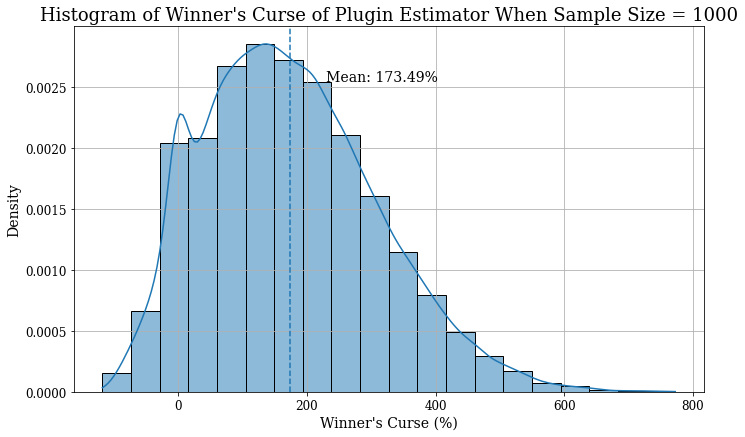

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {emp_wc_dstn_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title(f"Histogram of Winner's Curse of Plugin Estimator When Sample Size = {data_params['sample_size']}", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating Winner's Curse

In [15]:
def stratified_bootstrap(data: pd.DataFrame, boot_sample_size: int) -> pd.DataFrame:
    # Group by 'treatment' and 'segment'
    grouped = data.groupby(['treatment', 'segment'])
    
    # Calculate how much to sample per group
    total_combinations = grouped.ngroups
    group_base_size = boot_sample_size // total_combinations
    remainder = boot_sample_size % total_combinations

    # Prepare for sampling
    sampled_indices = []

    # Iterate over groups
    for name, group in grouped:
        # Calculate the group size (add 1 for groups until remainder is exhausted)
        group_size = group_base_size + (1 if remainder > 0 else 0)
        sampled_indices.extend(
            np.random.choice(group.index, group_size, replace=True)
        )
        remainder -= 1  # Decrement remainder for the next group if used

    return data.loc[sampled_indices]

## Standard Bootstrap

In [16]:
def get_wc_boot_dstn(
    data: pd.DataFrame, test_customers: np.ndarray,
    price: float, cost: float, 
    treatment_space: np.ndarray, 
    n_bootstraps: int = 500,
    **kwargs
) -> np.ndarray:
    # attributes
    sample_size = data.shape[0]

    # placeholder for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))

    # get treatment table estimated with all data
    emp_pom = PotentialOutcomeModel(
        treatment_space=treatment_space, 
    ).fit(data)
    emp_customer_te = match_customer_segment_with_te(
        customer_segments=test_customers, te_table=emp_pom.te_table
    )

    # create bootstrap distribution
    for boot_id in range(n_bootstraps):
        # bootstrap data
        boot_data = stratified_bootstrap(data=data, boot_sample_size=sample_size)

        # estimate the treatment effect table from table
        boot_pom = PotentialOutcomeModel(
            treatment_space=treatment_space
        ).fit(boot_data)
        boot_customer_te = match_customer_segment_with_te(
            customer_segments=test_customers, te_table=boot_pom.te_table
        )

        # optimize
        boot_targ_decision, boot_targ_val_est = optimize(
            test_customer_te=boot_customer_te, 
            treatment_space=treatment_space, price=price, cost=cost,
        )

        # evaluate boot_targ_decision with empirical treatment effects
        emp_boot_targ_val_est = objective_func(
            customer_te=emp_customer_te,  # evaluation criterion: empirical treatment effects
            targ_decision=boot_targ_decision,  # decision to be evaluated: bootstrapped decision
            price=price, cost=cost, 
            treatment_space=treatment_space, 
        )

        # calculate the winner's curse
        boot_wc_dstn_arr[boot_id] = boot_targ_val_est - emp_boot_targ_val_est

    return boot_wc_dstn_arr

In [16]:
dgp = MultipleTreatmentsMultipleSegments(**demand_params, seed=0)
data = dgp.sample(data_params['sample_size'], seed=0)
test_customers = dgp.sample_individuals(data_params['n_customers'], seed=0)

In [17]:
boot_wc_dstn_arr = get_wc_boot_dstn(
    data=data, test_customers=test_customers, 
    treatment_space=dgp.treatment_space, 
    **targeting_params, 
    n_bootstraps=500, seed=1
)

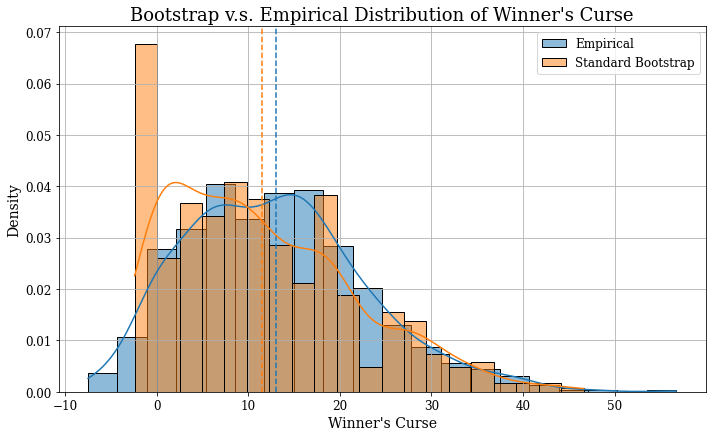

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [17]:
def get_wc_m_out_of_n_boot_dstn(
    data: pd.DataFrame, test_customers: np.ndarray,
    price: float, cost: float, 
    treatment_space: np.ndarray, 
    n_bootstraps: int = 500, power: float = 0.90, 
    seed: int = None, **kwargs
) -> np.ndarray:
    # parameter checks
    assert 0 < power < 1, 'Power should be between 0 and 1.' 

    # set seed
    if seed is not None:
        np.random.seed(seed)

    # attributes
    sample_size = data.shape[0]
    m = int(sample_size ** power)  # bootstrap sample size

    # placeholder for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))

    # get treatment table estimated with all data
    emp_pom = PotentialOutcomeModel(
        treatment_space=treatment_space, 
    ).fit(data)
    emp_customer_te = match_customer_segment_with_te(
        customer_segments=test_customers, te_table=emp_pom.te_table
    )

    # create bootstrap distribution
    for boot_id in range(n_bootstraps):
        # bootstrap data
        boot_data = stratified_bootstrap(data=data, boot_sample_size=m)

        # estimate the treatment effect table from table
        boot_pom = PotentialOutcomeModel(
            treatment_space=treatment_space
        ).fit(boot_data)
        boot_customer_te = match_customer_segment_with_te(
            customer_segments=test_customers, te_table=boot_pom.te_table
        )

        # optimize
        boot_targ_decision, boot_targ_val_est = optimize(
            test_customer_te=boot_customer_te, 
            treatment_space=treatment_space, price=price, cost=cost,
        )

        # evaluate boot_targ_decision with baseline treatment effects
        emp_boot_targ_val_est = objective_func(
            customer_te=emp_customer_te, 
            targ_decision=boot_targ_decision,
            price=price, cost=cost, 
            treatment_space=treatment_space, 
        )

        # calculate the winner's curse
        boot_wc_dstn_arr[boot_id] = boot_targ_val_est - emp_boot_targ_val_est

    return boot_wc_dstn_arr

In [20]:
dgp = MultipleTreatmentsMultipleSegments(**demand_params, seed=0)
data = dgp.sample(data_params['sample_size'], seed=0)
test_customers = dgp.sample_individuals(data_params['n_customers'], seed=0)

In [21]:
mnboot_wc_dstn_arr = get_wc_m_out_of_n_boot_dstn(
    data=data, test_customers=test_customers, 
    treatment_space=dgp.treatment_space, 
    **targeting_params, 
    n_bootstraps=500, power=0.95
)

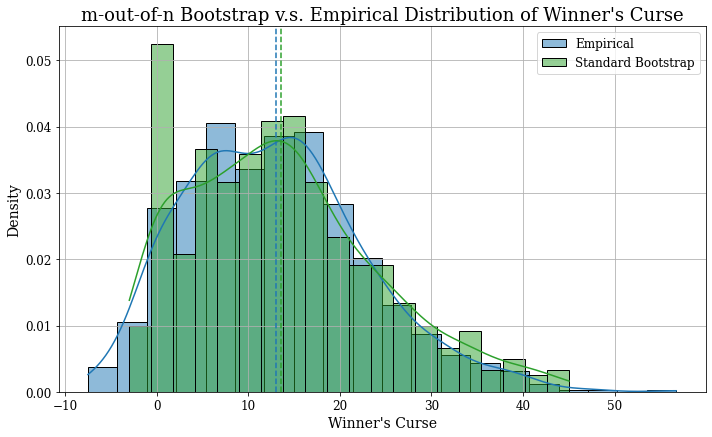

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(mnboot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='Standard Bootstrap')
ax.axvline(mnboot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [18]:
def get_wc_num_boot_dstn(
    data: pd.DataFrame, test_customers: np.ndarray,
    price: float, cost: float, 
    treatment_space: np.ndarray, 
    n_bootstraps: int = 500, power: float = -0.45, 
    seed: int = None, **kwargs
) -> np.ndarray:
    # parameter checks
    assert 0 > power > -0.5, "Power must be between 0 and -0.5"

    # set seed
    if seed is not None:
        np.random.seed(seed)

    # attributes
    sample_size = data.shape[0]
    epsilon_n = sample_size ** power  # epsilon_n

    # placeholder for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))

    # get treatment table estimated with all data
    emp_pom = PotentialOutcomeModel(
        treatment_space=treatment_space, 
    ).fit(data)
    emp_customer_te = match_customer_segment_with_te(
        customer_segments=test_customers, te_table=emp_pom.te_table
    )

    # create bootstrap distribution of treatment effects
    for boot_id in range(n_bootstraps):
        # bootstrap data
        boot_data = stratified_bootstrap(data=data, boot_sample_size=sample_size)

        # estimate the treatment effect table from pom
        boot_pom = PotentialOutcomeModel(
            treatment_space=treatment_space
        ).fit(boot_data)
        boot_customer_te = match_customer_segment_with_te(
            customer_segments=test_customers, te_table=boot_pom.te_table
        )  # shape = (sample_size, treatment_space - 1)
        
        # normalized error, shape = (n_segments, treatment_space - 1)
        norm_error = np.sqrt(sample_size) * (boot_pom.te_table.values - emp_pom.te_table.values) 

        # calculate perturbation
        perturb_te_table = emp_pom.te_table + epsilon_n * norm_error
        perturb_customer_te = match_customer_segment_with_te(
            customer_segments=test_customers, te_table=pd.DataFrame(perturb_te_table)
        )

        # solve optimization with bootstrap
        boot_targ_decision, _ = optimize(
            test_customer_te=boot_customer_te, 
            treatment_space=treatment_space, price=price, cost=cost,
        )

        # evaluate bootstrap policy under perturbed treatment effects
        perturb_targ_val_est = objective_func(
            customer_te=perturb_customer_te, 
            targ_decision=boot_targ_decision, 
            treatment_space=treatment_space, price=price, cost=cost
        )

        # evaluate bootstrap policy under empirical treatment effects
        emp_boot_targ_val_est = objective_func(
            customer_te=emp_customer_te, 
            targ_decision=boot_targ_decision, 
            treatment_space=treatment_space, price=price, cost=cost
        )

        # calculate the winner's curse
        boot_wc_dstn_arr[boot_id] = perturb_targ_val_est - emp_boot_targ_val_est

    return boot_wc_dstn_arr

In [24]:
dgp = MultipleTreatmentsMultipleSegments(**demand_params, seed=0)
data = dgp.sample(data_params['sample_size'], seed=0)
test_customers = dgp.sample_individuals(data_params['n_customers'], seed=0)

In [25]:
num_boot_wc_dstn_arr = get_wc_num_boot_dstn(
    data=data, test_customers=test_customers, 
    treatment_space=dgp.treatment_space, 
    **targeting_params, 
    n_bootstraps=500, power=-0.47
)

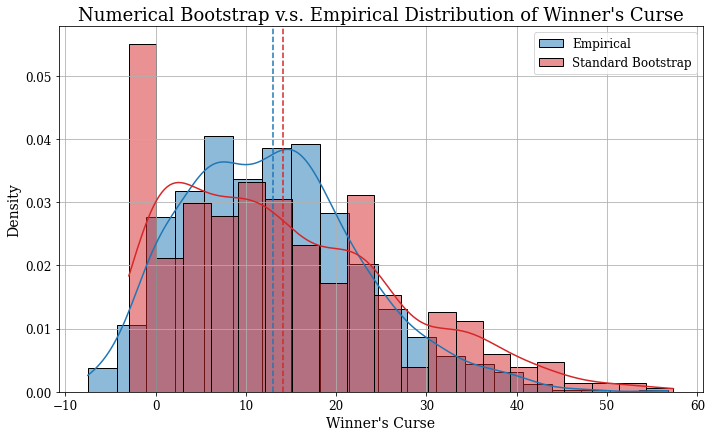

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Standard Bootstrap')
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [19]:
def bootstrap_correction_estimate(
    data: pd.DataFrame, test_customers: np.ndarray, 
    price: float, cost: float, treatment_space: np.ndarray, 
    bootstrap_method: str = 'standard', n_bootstraps: int = 500, 
    **kwargs, 
) -> np.ndarray:
    # solve plugin problem
    _, plugin_targ_val_est = estimate_then_optimize(
        data=data, test_customers=test_customers, 
        price=price, cost=cost, treatment_space=treatment_space, 
    )

    # dictionary of available bootstrap methods
    boot_methods_dict = {
        'standard': get_wc_boot_dstn, 
        'm_out_of_n': get_wc_m_out_of_n_boot_dstn, 
        'numerical': get_wc_num_boot_dstn, 
    }

    # get the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = boot_methods_dict[bootstrap_method](
        data=data, test_customers=test_customers, 
        price=price, cost=cost, 
        treatment_space=treatment_space, 
        n_bootstraps=n_bootstraps, **kwargs
    )

    return plugin_targ_val_est - boot_wc_dstn_arr.mean()

In [69]:
targeting_params = {'price': 1.5, 'cost': 0.1}
demand_params = {
    'n_segments': 2, 
    'te_diff': 0.05,
    'segment_func': lambda x: (x >= 0).astype(int),
    'treatment_space': np.array([0, 1, 2, 3]), 
    'noise_std': 3.0, 
}
data_params = {'sample_size': 10000, 'n_customers': 100}
experiment_params = {'n_experiments': 500}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 100}
    }, 
    'mn_boot_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95}
    }, 
    'num_boot_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.46}
    }
}

result_records = repeated_experiments(
    targeting_params=targeting_params, 
    demand_params=demand_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

100%|██████████| 500/500 [06:00<00:00,  1.39it/s]


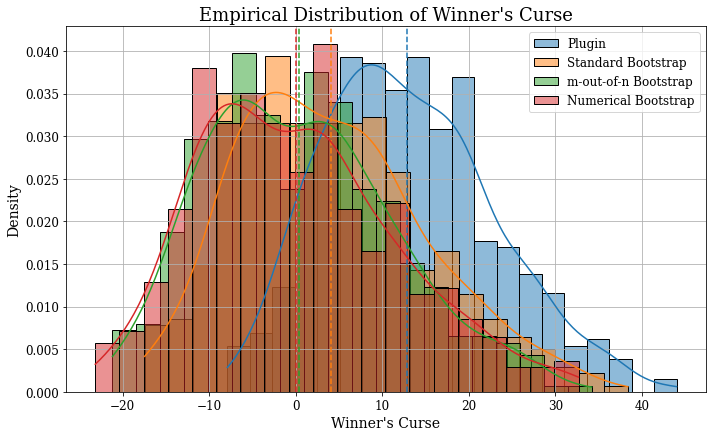

In [70]:
result_df = pd.DataFrame.from_records(result_records)
wc_df = result_df[[col for col in result_df.columns if col.endswith('wc')]].copy()
wc_df.rename(columns={col: col.replace('_wc', '') for col in wc_df.columns}, inplace=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_df['plugin'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Plugin')
ax.axvline(wc_df['plugin'].mean(), color='C0', linestyle='--')

sns.histplot(wc_df['bootstrap_correction'], bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(wc_df['bootstrap_correction'].mean(), color='C1', linestyle='--')

sns.histplot(wc_df['mn_boot_correction'], bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(wc_df['mn_boot_correction'].mean(), color='C2', linestyle='--')

sns.histplot(wc_df['num_boot_correction'], bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(wc_df['num_boot_correction'].mean(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [71]:
for col in wc_df.columns:
    mean = wc_df[col].mean()
    se = wc_df[col].std() / np.sqrt(data_params['sample_size'])
    print(f"{col}: {mean:.2f} ({se:.2f})")

plugin: 12.88 (0.10)
bootstrap_correction: 4.05 (0.11)
mn_boot_correction: 0.41 (0.11)
num_boot_correction: -0.01 (0.11)


# Sensitivity Analysis

## Sample Size

In [42]:
targeting_params = {'price': 1.5, 'cost': 0.1}
demand_params = {
    'n_segments': 2, 
    'te_diff': 0.05,
    'segment_func': lambda x: (x >= 0).astype(int),
    'treatment_space': np.array([0, 1, 2, 3]), 
    'noise_std': 3.0, 
    
}
data_params = {'sample_size': 1000, 'n_customers': 100}
experiment_params = {'n_experiments': 500}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500}
    }, 
    'mn_boot_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.95}
    }, 
    'num_boot_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.46}
    }
}

In [43]:
sample_size_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
result_dict = {sample_size: None for sample_size in sample_size_list}

for idx, sample_size in enumerate(sample_size_list):
    data_params['sample_size'] = sample_size

    result_records = repeated_experiments(
        targeting_params=targeting_params, 
        demand_params=demand_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in result_records]) 
        for name in list(estimators_dict.keys()) + ['plugin']
    })

    result_dict[sample_size] = {
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    }

    result_dict[sample_size].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

with open('results/case3_sample_size_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

100%|██████████| 500/500 [1:06:51<00:00,  8.02s/it]  


In [25]:
with open('results/case3_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

mean_df = result_df[[col for col in result_df.columns if col.endswith('mean')]].copy().rename({
    col: col.replace('_mean', '') for col in result_df.columns
}, axis=1)
se_df = result_df[[col for col in result_df.columns if col.endswith('se')]].copy().rename({
    col: col.replace('_se', '') for col in result_df.columns
}, axis=1)

In [27]:
result_df

,bootstrap_correction_mean,mn_boot_correction_mean,num_boot_correction_mean,plugin_mean,bootstrap_correction_se,mn_boot_correction_se,num_boot_correction_se,plugin_se
1000,13.507628,5.189314,4.396272,42.617243,1.051440,1.061824,1.093903,0.939541
2000,8.144650,1.559635,0.820595,28.813431,0.502132,0.505596,0.522949,0.455993
3000,7.419742,1.754119,1.055586,24.213772,0.345481,0.346389,0.359934,0.313392
4000,7.353488,2.270683,1.857012,21.335075,0.273727,0.274794,0.288235,0.243769
5000,5.227985,0.558166,0.076044,18.239698,0.209576,0.211402,0.220079,0.189495
6000,3.504067,-0.942942,-1.320049,15.087747,0.173295,0.173379,0.182000,0.155700
7000,4.671128,0.485850,0.086785,15.359064,0.151547,0.151186,0.157993,0.138265
8000,3.712759,-0.297266,-0.677574,13.812100,0.129921,0.130355,0.136117,0.118844
9000,4.687495,0.900036,0.606937,13.940444,0.126026,0.126764,0.132902,0.113852
10000,3.966235,0.372043,-0.032121,12.882984,0.107445,0.107366,0.112441,0.097633


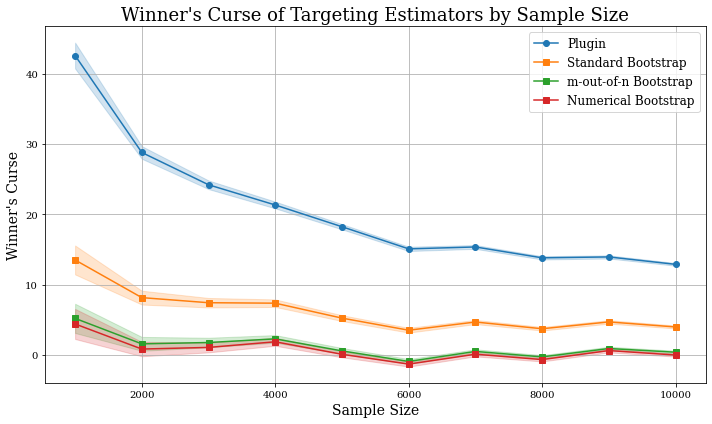

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plugin estimaotr
ax.plot(mean_df.index, mean_df['plugin'], 'o-', label='Plugin', color='C0')
ax.fill_between(
    mean_df.index, 
    mean_df['plugin'] - 1.96 * se_df['plugin'], 
    mean_df['plugin'] + 1.96 * se_df['plugin'], 
    color='C0', alpha=0.2
)

ax.plot(mean_df.index, mean_df['bootstrap_correction'], 's-', label='Standard Bootstrap', color='C1')
ax.fill_between(
    mean_df.index, 
    mean_df['bootstrap_correction'] - 1.96 * se_df['bootstrap_correction'], 
    mean_df['bootstrap_correction'] + 1.96 * se_df['bootstrap_correction'], 
    color='C1', alpha=0.2
)

# value correction with m-out-of-n bootstrap
ax.plot(mean_df.index, mean_df['mn_boot_correction'], 's-', label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    mean_df.index, 
    mean_df['mn_boot_correction'] - 1.96 * se_df['mn_boot_correction'], 
    mean_df['mn_boot_correction'] + 1.96 * se_df['mn_boot_correction'], 
    color='C2', alpha=0.2
)

# value correction with numerical bootstrap
ax.plot(mean_df.index, mean_df['num_boot_correction'], 's-', label='Numerical Bootstrap', color='C3')
ax.fill_between(
    mean_df.index, 
    mean_df['num_boot_correction'] - 1.96 * se_df['num_boot_correction'], 
    mean_df['num_boot_correction'] + 1.96 * se_df['num_boot_correction'], 
    color='C3', alpha=0.2
)

ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_title('Winner\'s Curse of Targeting Estimators by Sample Size', fontsize=title_size)
ax.grid()
ax.legend(fontsize=legend_label_size)

plt.tight_layout()
plt.show()